In [2]:
import os
import sys
import json
import textwrap

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.linear_model      import LinearRegression
from sklearn.ensemble          import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics           import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection        import permutation_importance

In [3]:

df = pd.read_csv("../data/processed/oil_production_features.csv")

df.head()

,country,year,production,lag1,lag2,lag3,rolling_3,country_code,decade
0,AGO,1974,8720.314,8325.190,7205.159,5841.110,7123.819667,0,1970s
1,AGO,1975,7954.569,8720.314,8325.190,7205.159,8083.554333,0,1970s
2,AGO,1976,7722.803,7954.569,8720.314,8325.190,8333.357667,0,1970s
3,AGO,1977,7210.264,7722.803,7954.569,8720.314,8132.562000,0,1970s
4,AGO,1978,6604.814,7210.264,7722.803,7954.569,7629.212000,0,1970s


In [10]:

FEATURES = ["year", "country_code", "lag1", "lag2", "lag3", "rolling_3"]
X = df[FEATURES]
y = df["production"]
SPLIT_YEAR = 2013 
# Time-based split (avoids future data leaking into training)
mask_train = df["year"] <= SPLIT_YEAR
X_train, y_train = X[mask_train],  y[mask_train]
X_test,  y_test  = X[~mask_train], y[~mask_train]

print(f"\n  Train: years ≤ {SPLIT_YEAR}  ({len(X_train):,} rows)")
print(f"  Test : years > {SPLIT_YEAR}  ({len(X_test):,} rows)")
print(f"  Test years: {sorted(df[~mask_train]['year'].unique())}")

models = {
    "Linear Regression" : LinearRegression(),
    "Random Forest"     : RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting" : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
print("\n  Training models …")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "model"  : model,
        "preds"  : preds,
        "r2"     : r2_score(y_test, preds),
        "mae"    : mean_absolute_error(y_test, preds),
        "rmse"   : np.sqrt(mean_squared_error(y_test, preds)),
    }

print(f"\n  {'Model':<25} {'R²':>8} {'MAE':>12} {'RMSE':>12}")
print("  " + "-" * 60)
for name, m in results.items():
    print(f"  {name:<25} {m['r2']:>8.4f} {m['mae']:>12,.1f} {m['rmse']:>12,.1f}")


  Train: years ≤ 2013  (5,009 rows)
  Test : years > 2013  (556 rows)
  Test years: [2014, 2015, 2016, 2017]

  Training models …

  Model                           R²          MAE         RMSE
  ------------------------------------------------------------
  Linear Regression           0.9959      1,608.6      5,228.0
  Random Forest               0.9867      2,291.6      9,397.4
  Gradient Boosting           0.9705      2,806.1     14,001.2


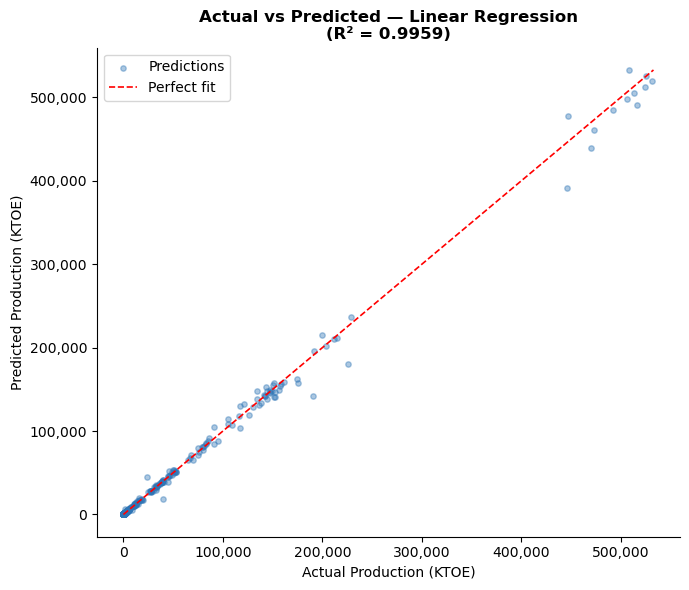


  Scatter plot saved → ../output\actual_vs_predicted.png


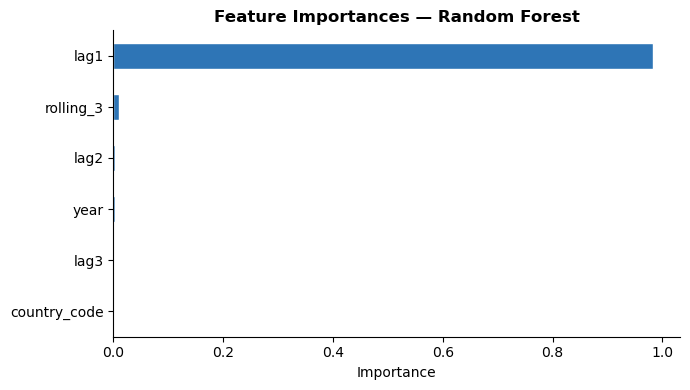

  Feature importance plot saved → ../output\feature_importance.png


In [11]:
best_name  = max(results, key=lambda k: results[k]["r2"])
best_preds = results[best_name]["preds"]
OUTPUT_DIR = "../output"
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, best_preds, alpha=0.4, s=15, color="#2E75B6", label="Predictions")
lims = [min(y_test.min(), best_preds.min()),
        max(y_test.max(), best_preds.max())]
ax.plot(lims, lims, "r--", linewidth=1.2, label="Perfect fit")
ax.set_xlabel("Actual Production (KTOE)")
ax.set_ylabel("Predicted Production (KTOE)")
ax.set_title(f"Actual vs Predicted — {best_name}\n(R² = {results[best_name]['r2']:.4f})",
             fontsize=12, fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
scatter_path = os.path.join(OUTPUT_DIR, "actual_vs_predicted.png")
plt.savefig(scatter_path, dpi=150)
plt.show()
print(f"\n  Scatter plot saved → {scatter_path}")

# --- Feature importance (Random Forest) ---
rf_model = results["Random Forest"]["model"]
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot.barh(ax=ax, color="#2E75B6", edgecolor="white")
ax.set_title("Feature Importances — Random Forest", fontsize=12, fontweight="bold")
ax.set_xlabel("Importance")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fi_path = os.path.join(OUTPUT_DIR, "feature_importance.png")
plt.savefig(fi_path, dpi=150)
plt.show()
print(f"  Feature importance plot saved → {fi_path}")

In [14]:

FEATURES2 = ["year", "country_code"]
X2 = df[FEATURES2]
y2 = df["production"]
SPLIT_YEAR = 2013 
# Time-based split (avoids future data leaking into training)
mask_train = df["year"] <= SPLIT_YEAR
X_train, y_train = X2[mask_train],  y2[mask_train]
X_test,  y_test  = X2[~mask_train], y2[~mask_train]

print(f"\n  Train: years ≤ {SPLIT_YEAR}  ({len(X_train):,} rows)")
print(f"  Test : years > {SPLIT_YEAR}  ({len(X_test):,} rows)")
print(f"  Test years: {sorted(df[~mask_train]['year'].unique())}")

models = {
    "Linear Regression" : LinearRegression(),
    "Random Forest"     : RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting" : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
print("\n  Training models …")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "model"  : model,
        "preds"  : preds,
        "r2"     : r2_score(y_test, preds),
        "mae"    : mean_absolute_error(y_test, preds),
        "rmse"   : np.sqrt(mean_squared_error(y_test, preds)),
    }

print(f"\n  {'Model':<25} {'R²':>8} {'MAE':>12} {'RMSE':>12}")
print("  " + "-" * 60)
for name, m in results.items():
    print(f"  {name:<25} {m['r2']:>8.4f} {m['mae']:>12,.1f} {m['rmse']:>12,.1f}")


  Train: years ≤ 2013  (5,009 rows)
  Test : years > 2013  (556 rows)
  Test years: [2014, 2015, 2016, 2017]

  Training models …

  Model                           R²          MAE         RMSE
  ------------------------------------------------------------
  Linear Regression           0.0056     44,905.2     81,352.3
  Random Forest               0.9773      3,360.5     12,281.6
  Gradient Boosting           0.8378     18,395.6     32,860.7


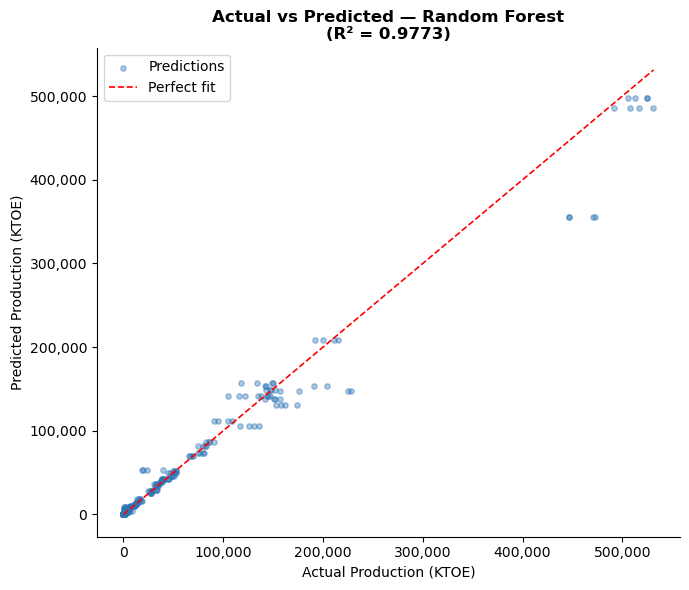


  Scatter plot saved → ../output\actual_vs_predicted2.png


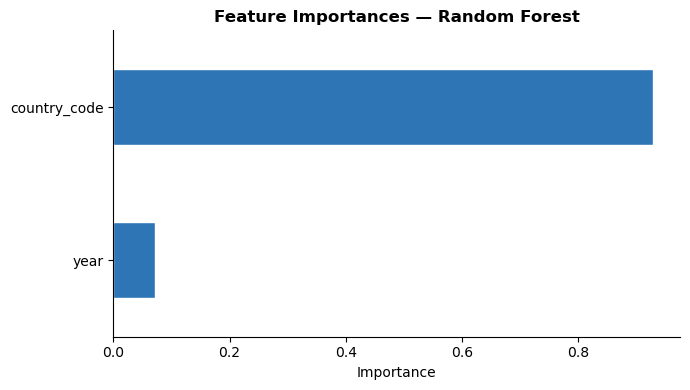

  Feature importance plot saved → ../output\feature_importance2.png


In [15]:
best_name  = max(results, key=lambda k: results[k]["r2"])
best_preds = results[best_name]["preds"]
OUTPUT_DIR = "../output"
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, best_preds, alpha=0.4, s=15, color="#2E75B6", label="Predictions")
lims = [min(y_test.min(), best_preds.min()),
        max(y_test.max(), best_preds.max())]
ax.plot(lims, lims, "r--", linewidth=1.2, label="Perfect fit")
ax.set_xlabel("Actual Production (KTOE)")
ax.set_ylabel("Predicted Production (KTOE)")
ax.set_title(f"Actual vs Predicted — {best_name}\n(R² = {results[best_name]['r2']:.4f})",
             fontsize=12, fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
scatter_path = os.path.join(OUTPUT_DIR, "actual_vs_predicted2.png")
plt.savefig(scatter_path, dpi=150)
plt.show()
print(f"\n  Scatter plot saved → {scatter_path}")

# --- Feature importance (Random Forest) ---
rf_model = results["Random Forest"]["model"]
importances = pd.Series(rf_model.feature_importances_, index=FEATURES2).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot.barh(ax=ax, color="#2E75B6", edgecolor="white")
ax.set_title("Feature Importances — Random Forest", fontsize=12, fontweight="bold")
ax.set_xlabel("Importance")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fi_path = os.path.join(OUTPUT_DIR, "feature_importance2.png")
plt.savefig(fi_path, dpi=150)
plt.show()
print(f"  Feature importance plot saved → {fi_path}")